In [33]:
!pip install kagglehub -q

In [34]:
!pip install torchvision -q

In [35]:
import kagglehub

path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flickr8k' dataset.
Path to dataset files: /kaggle/input/flickr8k


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import os
import string

import pickle
import random
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from nltk.translate.bleu_score import corpus_bleu

from collections import Counter
from PIL import Image
import nltk

In [37]:
EMBEDDING_SIZE = 256
HIDDEN_SIZE = 512
BATCH_SIZE = 64

IMAGE_PATH = "/kaggle/input/flickr8k/Images"
CAPTION_PATH = "/kaggle/input/flickr8k/captions.txt"

BEST_CHECKPOINT = "best_checkpoint.pth"
BEST_MODEL_PATH = "best_model.pth"
VOCAB_PATH = "vocab.pkl"
np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda



## Класс Словаря

In [38]:
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

class Vocabulary:
    def __init__(self, freq_threshold=3):
        self.freq_threshold = freq_threshold
        self.word2ind = {
            '<bos>':0,
            '<eos>':1,
            '<unk>':2,
            '<pad>':3
        }
        self.ind2word = {i: c for c, i in self.word2ind.items()}

    def __len__(self):
        return len(self.word2ind)

    def tokenize(self,text):
        processed_text = text.lower().translate(str.maketrans('', '', string.punctuation))
        tokens = word_tokenize(processed_text)
        return tokens

    def build_vocabulary(self, sentence_list):
        counter = Counter()

        for sentence in sentence_list:
            tokenized_sentence = self.tokenize(sentence)
            for token in tokenized_sentence:
                counter[token] += 1

        index = len(self.word2ind)

        for word, cnt in counter.items():
            if cnt >= self.freq_threshold:
                self.word2ind[word] = index
                self.ind2word[index] = word
                index += 1

    def number(self, text):
        tokenized_text = self.tokenize(text)
        number_text = []
        for token in tokenized_text:
            number_text.append(self.word2ind.get(token, self.word2ind['<unk>']))
        return number_text

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [39]:
def parse(csv_file):
    imgid2caption = {}
    df = pd.read_csv(csv_file)

    for _, row in df.iterrows():
        img_id = row['image'].strip()
        caption = row['caption'].strip()

        if not img_id or not caption:
            continue
        if img_id not in imgid2caption:
            imgid2caption[img_id] = []
        imgid2caption[img_id].append(caption)

    return imgid2caption

In [40]:
imgid2caption = parse(CAPTION_PATH)
for el in imgid2caption:
    print(f'{el}: {imgid2caption[el]}')
    break

1000268201_693b08cb0e.jpg: ['A child in a pink dress is climbing up a set of stairs in an entry way .', 'A girl going into a wooden building .', 'A little girl climbing into a wooden playhouse .', 'A little girl climbing the stairs to her playhouse .', 'A little girl in a pink dress going into a wooden cabin .']


In [41]:
captions = []
for el in imgid2caption.values():
    captions.extend(el)

vocab = Vocabulary(freq_threshold=3)
vocab.build_vocabulary(captions)

## Класс Датасета

In [42]:
class MyDataset(Dataset):
    def __init__(self, imgid2caption, vocab, transform=None):
        self.imgid2captions = []
        self.vocab = vocab
        self.transform = transform

        for img, captions in imgid2caption.items():
            for caption in captions:
                self.imgid2captions.append((img, caption))

    def __len__(self):
        return len(self.imgid2captions)

    def __getitem__(self, index):
        img_id, caption = self.imgid2captions[index]

        img_path = os.path.join(IMAGE_PATH, img_id)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        number_caption = [self.vocab.word2ind['<bos>']]
        number_caption += self.vocab.number(caption)
        number_caption += [self.vocab.word2ind['<eos>']]

        number_caption = torch.tensor(number_caption, dtype=torch.long)
        return image, number_caption


In [43]:
dataset = MyDataset(imgid2caption, vocab, None)

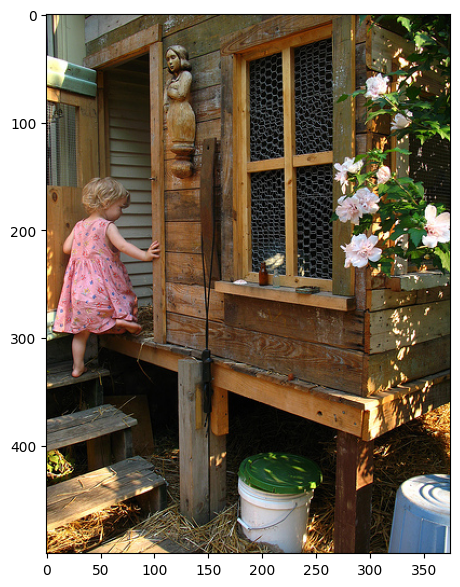

tensor([ 0,  4,  5,  6,  4,  7,  8,  9, 10, 11,  4, 12, 13, 14,  6, 15,  2, 16,
         1])
1000268201_693b08cb0e.jpg: ['A child in a pink dress is climbing up a set of stairs in an entry way .', 'A girl going into a wooden building .', 'A little girl climbing into a wooden playhouse .', 'A little girl climbing the stairs to her playhouse .', 'A little girl in a pink dress going into a wooden cabin .']


In [44]:
image = dataset[0][0]
fig = plt.figure(figsize=(10,7))
ax = plt.subplot(111)
plt.imshow(image)
plt.show()
print(dataset[0][1])
for el in imgid2caption:
    print(f'{el}: {imgid2caption[el]}')
    break

In [45]:
def collate_fn_with_padding(input_batch, pad_id=vocab.word2ind['<pad>']):
    images = [item[0] for item in input_batch]
    captions = [item[1].tolist() for item in input_batch]

    seq_lens = [len(x) for x in captions]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in captions:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    images = torch.stack(images, dim=0)
    padded_captions = torch.LongTensor(new_batch)
    return images, padded_captions, seq_lens

## Класс Модели

In [46]:
class Encoder(nn.Module):
    def __init__(self, embedding_size):
        super(Encoder, self).__init__()
        resnet = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
        for param in resnet.parameters():
            param.requires_grad = False
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)

        self.fc = nn.Linear(resnet.fc.in_features, embedding_size)
        self.batch_norm = nn.BatchNorm1d(embedding_size, momentum=0.01)

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)
        features = features.view(features.size(0), -1)
        features = self.fc(features)
        features = self.batch_norm(features)
        return features

In [48]:
class Decoder(nn.Module):
    def __init__(self, embedding_size, hidden_size, vocab_size, num_layers=1):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.dropout = nn.Dropout(0.3)
        self.lstm = nn.LSTM(embedding_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        captions_in = captions[:, :-1]
        embedding = self.dropout(self.embedding(captions_in))
        features = features.unsqueeze(1)
        lstm_input = torch.cat((features, embedding), dim=1)
        outputs, _ = self.lstm(lstm_input)
        logits = self.fc(outputs)
        return logits

In [94]:
class MyImageCaptioningModel(nn.Module):
    def __init__(self, encoder, decoder):
        super(MyImageCaptioningModel, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

## Pipeline для обучения

In [50]:
def train_one_epoch(model, criterion, optimizer, dataloader,vocab_size):
    model.train()
    total_loss = 0.0

    for images, captions, lenghts in tqdm(dataloader):
        images = images.to(device)
        captions = captions.to(device)
        optimizer.zero_grad()
        pred = model(images, captions)
        pred = pred[:, 1:, :].contiguous().view(-1, vocab_size)
        targets = captions[:, 1:].contiguous().view(-1)

        loss = criterion(pred, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    return avg_loss

In [51]:
def validate(model, criterion, dataloader, vocab_size):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, captions, lengths in dataloader:
            images = images.to(device)
            captions = captions.to(device)
            outputs = model(images, captions)
            outputs = outputs[:, 1:, :].contiguous().view(-1, vocab_size)
            targets = captions[:, 1:].contiguous().view(-1)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
    avg_val_loss = total_loss / len(dataloader)
    return avg_val_loss

In [52]:
def fit(epochs, model, loss_func, optimizer, train_dl, val_dl, vocab_size):
  train_losses = []
  val_losses = []
  best_val_loss = float('inf')

  for epoch in tqdm(range(epochs)):
    train_loss = train_one_epoch(model, loss_func, optimizer, train_dl, vocab_size)
    val_loss = validate(model, loss_func, val_dl, vocab_size)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), BEST_CHECKPOINT)

    print(f"EPOCH {epoch + 1} |"
          f"train_loss {train_loss:.4f} |"
          f"val_loss {val_loss:.4f}")
  return train_losses, val_losses

In [53]:
imgid2caption = parse(CAPTION_PATH)
img_ids = list(imgid2caption.keys())

In [54]:
captions = []
for el in imgid2caption.values():
    captions.extend(el)

vocab = Vocabulary(freq_threshold=3)
vocab.build_vocabulary(captions)

with open(VOCAB_PATH, 'wb') as f:
    pickle.dump(vocab, f)

train_ids, valid_ids = train_test_split(img_ids, test_size=0.2, random_state=42, shuffle=True)
train_dict = {id: imgid2caption[id] for id in train_ids}
valid_dict = {id: imgid2caption[id] for id in valid_ids}

In [55]:
transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

train_dataset = MyDataset(train_dict, vocab, transform=transform)
valid_dataset = MyDataset(valid_dict, vocab, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn_with_padding, num_workers=2, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn_with_padding, num_workers=2, shuffle=False)

In [56]:
encoder = Encoder(EMBEDDING_SIZE)
decoder = Decoder(EMBEDDING_SIZE, HIDDEN_SIZE, vocab_size=len(vocab))
model = MyImageCaptioningModel(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2ind['<pad>'])

parameters = list(model.decoder.parameters()) + list(model.encoder.fc.parameters()) + list(model.encoder.batch_norm.parameters())
optimizer = torch.optim.Adam(parameters, lr=1e-3)

In [58]:
result = fit(10, model, criterion, optimizer, train_dataloader, valid_dataloader, vocab_size=len(vocab))

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/506 [00:00<?, ?it/s]

EPOCH 1 |train_loss 3.5988 |val_loss 3.2352


  0%|          | 0/506 [00:00<?, ?it/s]

EPOCH 2 |train_loss 2.9983 |val_loss 3.0162


...

EPOCH 8 |train_loss 2.0174 |val_loss 2.9026


  0%|          | 0/506 [00:00<?, ?it/s]

EPOCH 9 |train_loss 1.9275 |val_loss 2.9262


  0%|          | 0/506 [00:00<?, ?it/s]

EPOCH 10 |train_loss 1.8476 |val_loss 2.9634


## Графики loss обучения и валидации

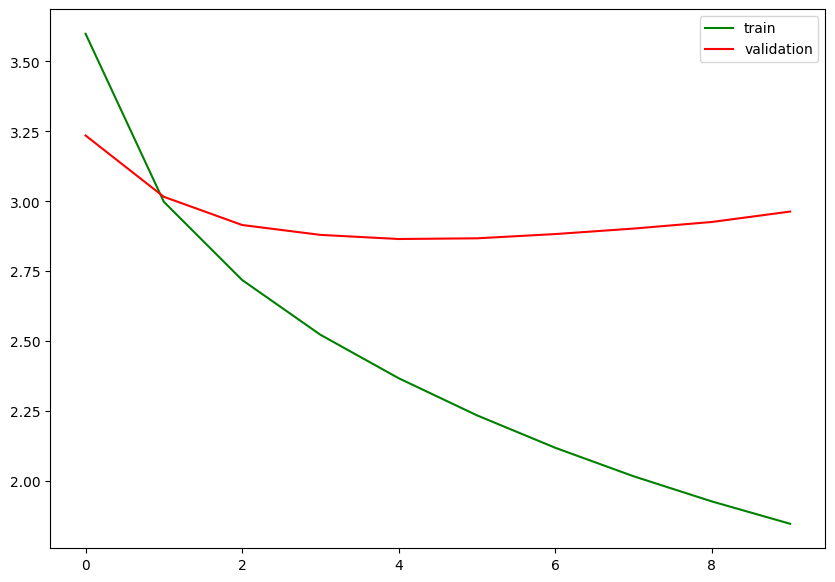

In [60]:
fig = plt.figure(figsize=(10,7))
ax = plt.subplot(111)

plt.plot(result[0], color='green')
plt.plot(result[1], color='red')

labels = ['train', 'validation']
plt.legend(labels=labels)

plt.show()

## Inference

In [102]:
def predict_caption(model, image_path, vocab, transform, max_len=20):
    model.eval()

    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    result_ids = [vocab.word2ind['<bos>']]

    with torch.no_grad():
        features = model.encoder(image)

        for _ in range(max_len):
            caption_tensor = torch.tensor([result_ids], dtype=torch.long).to(device)

            outputs = model.decoder(features, caption_tensor)
            logits = outputs[:, -1, :]
            predicted_id = logits.argmax(dim=1).item()

            if predicted_id == vocab.word2ind['<eos>']:
                break

            result_ids.append(predicted_id)

    result_caption = []
    for idx in result_ids[1:]:
        word = vocab.ind2word[idx]
        if word not in ['<bos>', '<eos>', '<pad>', '<unk>']:
            result_caption.append(word)

    return ' '.join(result_caption)

In [108]:
actual = []
predicted = []

for img_id in tqdm(valid_dict):
    captions = valid_dict[img_id]
    image_path = os.path.join(IMAGE_PATH, img_id)

    y_pred = predict_caption(model, image_path, vocab, transform, max_len=10)

    actual_captions = [caption.split() for caption in captions]
    y_pred = y_pred.split()

    actual.append(actual_captions)
    predicted.append(y_pred)

print("BLEU-1:", corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))

  0%|          | 0/1619 [00:00<?, ?it/s]

BLEU-1: 0.5120026355348392


In [75]:
encoder = Encoder(EMBEDDING_SIZE)
decoder = Decoder(EMBEDDING_SIZE, HIDDEN_SIZE, vocab_size=len(vocab))
model = MyImageCaptioningModel(encoder, decoder).to(device)

model.load_state_dict(torch.load(BEST_CHECKPOINT, map_location=device))
model.eval()

MyImageCaptioningModel(
  (encoder): Encoder(
    (resnet): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=Tr

an a elderly man man with wearing a sunglasses black


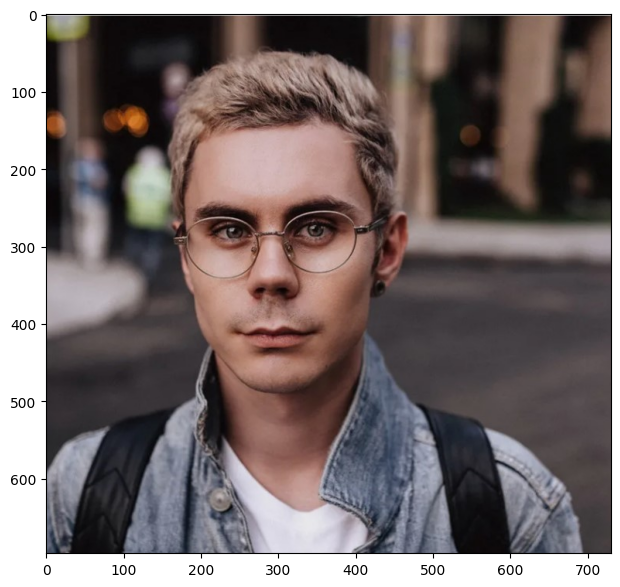

In [106]:
fig = plt.figure(figsize=(10,7))
ax = plt.subplot(111)

img_path = '/content/smart_man.jpg'
image = Image.open(img_path).convert('RGB')
plt.imshow(image)

print(predict_caption(model, img_path, vocab, transform))